# Sweep strategy — parameter sandbox

Play with the knobs in **Params** and re-run. Everything downstream reads from there.

**Read before trusting any number in here.**

- 118 logged sweeps, ~51 tradeable after the earnings / delta / degenerate-quote /
  history filters. That is a small sample and every result has confidence intervals
  that cross zero.
- Real sweeps beat random entries by **+11.9 pts**, but one-sided **p = 0.25** — a
  quarter of random draws beat it. Signal-shaped, not significant.
- No sweep-native feature (premium, moneyness, IV, delta, vol/OI, time of day)
  survives a cluster bootstrap. Premium size has IC 0.013.
- Sizing here deploys the full `PER_POS` on every signal regardless of remaining
  equity, so cumulative losses can exceed the account. Treat totals as indicative.
- Options are priced Black-Scholes at the vendor's IV **held constant**, so there is
  no vega P&L, and fills carry no spread or slippage.

See `research/sweep_events/strategy.md` and `notes/entry_gate_checks.md`.

## Params

In [1]:
# ---- account & sizing ----
CAPITAL      = 50_000
PER_POS      = 10_000     # per position; whole contracts only

# ---- exits ----
STOP_PCT     = 60.0       # premium stop, None to disable
TARGET_PCT   = None       # profit target, None to disable

# ---- which sweeps to take ----
DELTA_MIN, DELTA_MAX = 0.30, 0.70
MAX_IV       = None       # e.g. 150.0 to reject squeeze-priced sweeps
MIN_PREMIUM  = None       # $M floor, e.g. 2.0
RIGHTS       = ('C', 'P') # ('C',) for calls only
MIN_HISTORY  = 120        # sessions of bars required before the sweep

# ---- which contract we buy ----
# 'monthly'      third-Friday monthly, never earlier than the sweep's own expiry
# 'match'        copy the sweep's expiry
# 'match_if_short' copy when the sweep DTE <= SHORT_DTE, else monthly
EXPIRY_RULE  = 'match_if_short'
SHORT_DTE    = 3          # 0-3d sweeps: theirs +30%, monthly -45%
MIN_DAYS     = 7          # monthly must be at least this far out
STRIKE_RULE  = 'atm'      # 'atm' or 'match'

## Setup

In [2]:
import sys, warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / 'research').exists(): ROOT = ROOT.parent
sys.path[:0] = [str(ROOT), str(ROOT / 'research' / 'sweep_events')]

from backtest.data import load_bars
from gates import _bs, split_factor
from backtest_strategy import third_friday, next_monthly, atm_strike

SURF, INK2, MUTED = '#fcfcfb', '#52514e', '#b8b7b0'
CAT = ['#2a78d6','#eb6834','#1baf7a','#eda100','#e87ba4','#008300']
plt.rcParams.update({'figure.facecolor':SURF,'axes.facecolor':SURF,
    'axes.edgecolor':MUTED,'axes.labelcolor':INK2,'xtick.color':INK2,
    'ytick.color':INK2,'font.size':9,'axes.spines.top':False,'axes.spines.right':False})

sweeps = pd.read_parquet(ROOT/'research/sweep_events/sweeps.parquet')
print(f'{len(sweeps)} logged   {sweeps.tradeable.sum()} pass the log filters')

118 logged   53 pass the log filters


## Market context — SPY, QQQ, and a 10Y proxy

Alpaca serves equities and ETFs only; there is **no yield index** (TNX returns no
bars). `IEF` (7-10Y Treasuries) stands in, and the implied yield change is derived
from its price with `Δy ≈ -Δp% / duration`. That is a proxy for the *direction and
rough scale* of rate moves — it is not the 10-year yield.

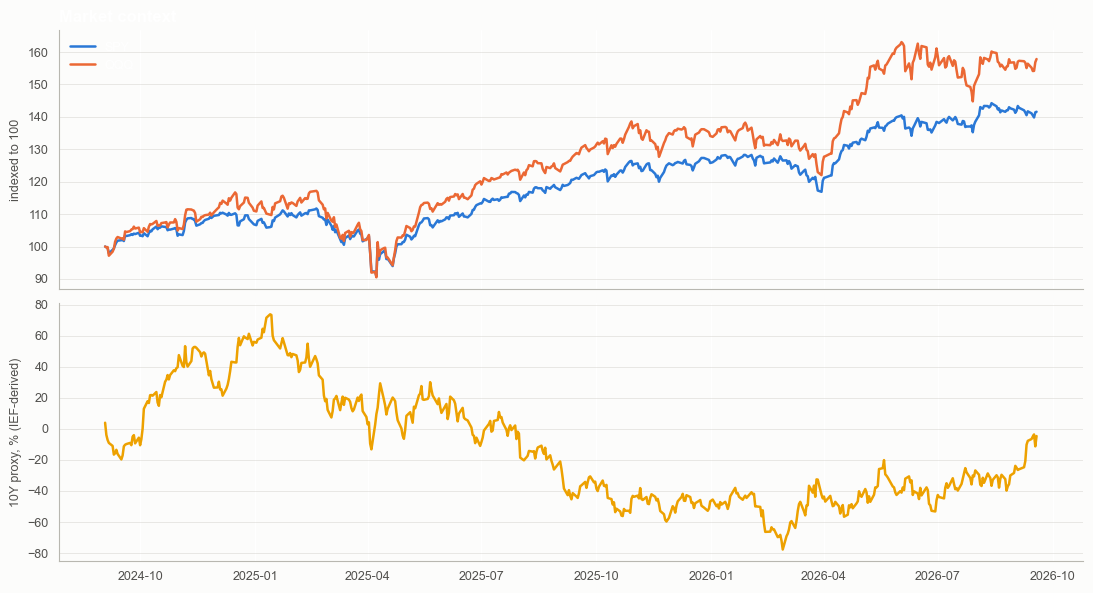

In [10]:
mkt_h = load_bars(['SPY','QQQ','IEF','TLT'], '2025-09-19', timeframe='1Hour',
                  session='regular').frame['close'].unstack('symbol').sort_index()
mkt_d = load_bars(['SPY','QQQ','IEF','TLT'], '2024-09-01', timeframe='1Day'
                  ).frame['close'].unstack('symbol')
mkt_d.index = pd.to_datetime(mkt_d.index.date)

IEF_DURATION = 7.5   # years, approximate effective duration
y0 = 4.0             # anchor level in %, arbitrary: only CHANGES are meaningful
mkt_d['y10_proxy'] = y0 - (mkt_d.IEF / mkt_d.IEF.iloc[0] - 1) * 100 / IEF_DURATION * 100
mkt_h['y10_proxy'] = y0 - (mkt_h.IEF / mkt_h.IEF.iloc[0] - 1) * 100 / IEF_DURATION * 100

fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for c, col in zip(['SPY','QQQ'], CAT):
    ax[0].plot(mkt_d.index, mkt_d[c]/mkt_d[c].iloc[0]*100, color=col, lw=1.8, label=c)
ax[0].set_ylabel('indexed to 100'); ax[0].legend(frameon=False)
ax[0].set_title('Market context', loc='left', weight='bold', fontsize=12)
ax[1].plot(mkt_d.index, mkt_d.y10_proxy, color=CAT[3], lw=1.8)
ax[1].set_ylabel('10Y proxy, % (IEF-derived)')
for a in ax: a.grid(axis='y', color=MUTED, alpha=.35, lw=.6); a.set_axisbelow(True)
plt.tight_layout(); plt.show()

## Backtest

One function, driven entirely by the Params cell. Every sweep is priced from bars
that had **closed** before the print, and the vendor's spot is reconciled against
the bars so a post-sweep split cannot fabricate a return.

In [4]:
def choose_expiry(swept_at, sweep_expiry, sweep_dte, rule, short_dte, min_days):
    """Which contract we buy. `rule` is passed in and never read from a global —
    reading the global silently made every expiry-rule comparison identical."""
    if rule == 'match':
        return pd.Timestamp(sweep_expiry)
    if rule == 'match_if_short' and sweep_dte <= short_dte:
        return pd.Timestamp(sweep_expiry)
    return next_monthly(pd.Timestamp(swept_at), min_days, pd.Timestamp(sweep_expiry))


def backtest(sw=None, **over):
    g = dict(CAPITAL=CAPITAL, PER_POS=PER_POS, STOP_PCT=STOP_PCT, TARGET_PCT=TARGET_PCT,
             DELTA_MIN=DELTA_MIN, DELTA_MAX=DELTA_MAX, MAX_IV=MAX_IV,
             MIN_PREMIUM=MIN_PREMIUM, RIGHTS=RIGHTS, MIN_HISTORY=MIN_HISTORY,
             STRIKE_RULE=STRIKE_RULE, EXPIRY_RULE=EXPIRY_RULE,
             SHORT_DTE=SHORT_DTE, MIN_DAYS=MIN_DAYS)
    g.update(over)
    sw = (sweeps if sw is None else sw).copy()
    sw = sw[sw.earnings_in_window.isna() & ~sw.degenerate_quote]
    sw = sw[sw.vendor_delta.abs().between(g['DELTA_MIN'], g['DELTA_MAX'])]
    sw = sw[sw.right.isin(g['RIGHTS'])]
    if g['MAX_IV']:      sw = sw[sw.vendor_iv <= g['MAX_IV']]
    if g['MIN_PREMIUM']: sw = sw[sw.premium_musd >= g['MIN_PREMIUM']]
    if sw.empty: return pd.DataFrame()

    bars = load_bars(sorted(sw.symbol.unique()), '2025-09-19',
                     timeframe='1Hour', session='regular').frame
    close = bars['close'].unstack('symbol').sort_index(); last = close.index[-1]
    rows = []
    for _, s in sw.iterrows():
        d = bars.xs(s.symbol, level='symbol').sort_index()
        ser = d.close; tz = ser.index.tz
        t0 = pd.Timestamp(s.swept_at, tz=tz)
        if (ser.index < t0).sum() < g['MIN_HISTORY']: continue
        i = max(0, min(ser.index.searchsorted(t0, side='right') - 1, len(ser) - 1))
        f, ok = split_factor(s.spot, ser.iloc[i], bar_low=d.low.iloc[i], bar_high=d.high.iloc[i])
        if not ok: continue
        spot, sweep_K, paid = s.spot / f, s.strike / f, s.price / f

        ed = choose_expiry(s.swept_at, s.expiry, s.dte,
                           g['EXPIRY_RULE'], g['SHORT_DTE'], g['MIN_DAYS'])
        exp = pd.Timestamp(ed, tz=tz) + pd.Timedelta(hours=16)
        K = atm_strike(spot) if g['STRIKE_RULE'] == 'atm' else sweep_K
        iv = s.vendor_iv / 100
        T0 = (exp - t0).total_seconds() / 86400 / 365
        if T0 <= 0: continue
        prem = _bs(spot, K, T0, iv, s.right)
        if prem <= 1e-6: continue
        seg = ser[(ser.index >= t0) & (ser.index <= min(exp, last))]
        if seg.empty: continue
        T = np.maximum((exp - seg.index).total_seconds() / 86400 / 365, 1e-9)
        pnl = (np.array([_bs(S, K, t, iv, s.right) for S, t in zip(seg.values, T)]) / prem - 1) * 100

        ti = np.flatnonzero(pnl >= g['TARGET_PCT'])[:1] if g['TARGET_PCT'] else []
        si = np.flatnonzero(pnl <= -g['STOP_PCT'])[:1] if g['STOP_PCT'] else []
        ft = ti[0] if len(ti) else 10**9
        fs = si[0] if len(si) else 10**9
        ret = (g['TARGET_PCT'] if ft < fs else -g['STOP_PCT'] if fs < ft else pnl[-1])

        cost = prem * 100; n = int(g['PER_POS'] // cost)
        rows.append(dict(sweep=s.label, symbol=s.symbol, swept_at=t0, right=s.right,
            our_K=K, our_exp=ed.strftime('%Y-%m-%d'), sweep_dte=s.dte,
            iv=s.vendor_iv, premium_musd=s.premium_musd, split=f,
            cost=round(cost), n=n, deployed=round(n * cost),
            ret=round(ret, 1), pnl=round(n * cost * ret / 100),
            hold_ret=round(pnl[-1], 1), mae=round(pnl.min(), 1), mfe=round(pnl.max(), 1),
            exit=('target' if ft < fs else 'stop' if fs < ft else 'expiry'),
            open=exp > last))
    return pd.DataFrame(rows)


def summarise(r, capital=None):
    capital = capital or CAPITAL
    t = r[r.n > 0]
    return dict(signals=len(r), traded=len(t), unaffordable=len(r) - len(t),
                pnl=int(t.pnl.sum()), pct_of_acct=round(100 * t.pnl.sum() / capital, 1),
                mean_ret=round(r.ret.mean(), 1), median_ret=round(r.ret.median(), 1),
                win=round(100 * (r.ret > 0).mean()), stopped=int((r.exit == 'stop').sum()),
                still_open=int(r.open.sum()))


res = backtest()
pd.Series(summarise(res)).to_frame('value')

,value
signals,51.0
traded,47.0
unaffordable,4.0
pnl,46027.0
pct_of_acct,92.1
mean_ret,17.3
median_ret,-60.0
win,29.0
stopped,36.0
still_open,3.0


In [5]:
pd.set_option('display.width', 220)
res.sort_values('ret', ascending=False)[
    ['sweep','right','our_exp','sweep_dte','cost','n','ret','hold_ret','mae','mfe','exit','open']
].to_string(index=False)

'            sweep right    our_exp  sweep_dte  cost  n   ret  hold_ret    mae   mfe   exit  open\n     MU 5/22 565C     C 2026-06-19      18.00  6884  1 730.7     730.7    5.4 743.4 expiry False\n     MU 5/15 480C     C 2026-05-15      31.00  3535  2 703.4     703.4  -10.3 944.2 expiry False\n    SNDK 3/6 575P     P 2026-03-06       1.00  1061  9 398.1     398.1   40.8 398.1 expiry False\n    MU 6/26 1230P     P 2026-06-26       1.00  4009  2 217.4     217.4    9.7 217.4 expiry False\n    CVNA 4/2 290C     C 2026-04-17      10.00   571 17 207.3     207.3  -52.2 235.0 expiry False\n    MU 7/15 1000P     P 2026-07-17       6.00  5939  1 196.0     196.0   -1.4 205.5 expiry False\n  SNDK 7/10 2060P     P 2026-07-17      25.00 26210  0 174.2     174.2  -55.8 174.2 expiry False\n    MU 9/11 1050P     P 2026-09-11       2.23  2194  4 128.2     128.2  -10.1 134.0 expiry False\n    POET 7/17 17P     P 2026-07-17      57.00   343 29 122.3     122.3  -21.6 122.9 expiry False\n  SNDK 7/10 1880C  

## Sweep a parameter

`grid()` re-runs the backtest across values of one knob. Bear the sample size in
mind: picking the argmax of a sweep over ~50 trades is fitting, not discovery.

In [6]:
def grid(param, values, **fixed):
    out = []
    for v in values:
        r = backtest(**{param: v, **fixed})
        if r.empty: continue
        out.append({param: v, **summarise(r)})
    return pd.DataFrame(out)

g_stop = grid('STOP_PCT', [30, 40, 50, 60, 70, 80, 90, None])
g_stop

,STOP_PCT,signals,traded,unaffordable,pnl,pct_of_acct,mean_ret,median_ret,win,stopped,still_open
0,30.0,51,47,4,100343,200.7,27.3,-30.0,20,41,3
1,40.0,51,47,4,71685,143.4,20.2,-40.0,22,40,3
2,50.0,51,47,4,39111,78.2,12.4,-50.0,22,40,3
3,60.0,51,47,4,46027,92.1,17.3,-60.0,29,36,3
4,70.0,51,47,4,59980,120.0,20.9,-70.0,33,29,3
5,80.0,51,47,4,40953,81.9,17.2,-80.0,35,28,3
6,90.0,51,47,4,19564,39.1,12.3,-90.0,35,27,3
7,NaN,51,47,4,30396,60.8,14.0,-53.5,39,0,3


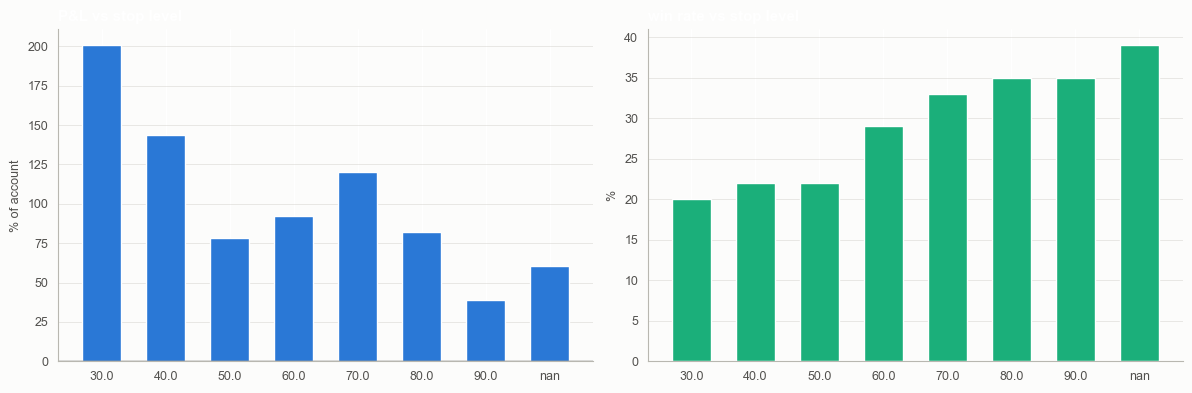

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
x = [str(v) for v in g_stop.STOP_PCT]
ax[0].bar(x, g_stop.pct_of_acct, color=CAT[0], width=.6)
ax[0].axhline(0, color=INK2, lw=1)
ax[0].set_title('P&L vs stop level', loc='left', weight='bold'); ax[0].set_ylabel('% of account')
ax[1].bar(x, g_stop.win, color=CAT[2], width=.6)
ax[1].set_title('win rate vs stop level', loc='left', weight='bold'); ax[1].set_ylabel('%')
for a in ax: a.grid(axis='y', color=MUTED, alpha=.35, lw=.6); a.set_axisbelow(True)
plt.tight_layout(); plt.show()

In [8]:
grid('PER_POS', [2_000, 5_000, 10_000, 15_000, 25_000])

,PER_POS,signals,traded,unaffordable,pnl,pct_of_acct,mean_ret,median_ret,win,stopped,still_open
0,2000,51,21,30,-5955,-11.9,17.3,-60.0,29,36,3
1,5000,51,43,8,1601,3.2,17.3,-60.0,29,36,3
2,10000,51,47,4,46027,92.1,17.3,-60.0,29,36,3
3,15000,51,49,2,113810,227.6,17.3,-60.0,29,36,3
4,25000,51,49,2,184021,368.0,17.3,-60.0,29,36,3


In [9]:
# expiry rule — the 0-3 DTE finding lives here
grid('EXPIRY_RULE', ['monthly', 'match', 'match_if_short'])

,EXPIRY_RULE,signals,traded,unaffordable,pnl,pct_of_acct,mean_ret,median_ret,win,stopped,still_open
0,monthly,51,38,13,-1931,-3.9,0.1,-60.0,24,39,6
1,match,51,49,2,-23039,-46.1,-3.3,-60.0,24,39,2
2,match_if_short,51,47,4,46027,92.1,17.3,-60.0,29,36,3


## Outcome distribution and market backdrop

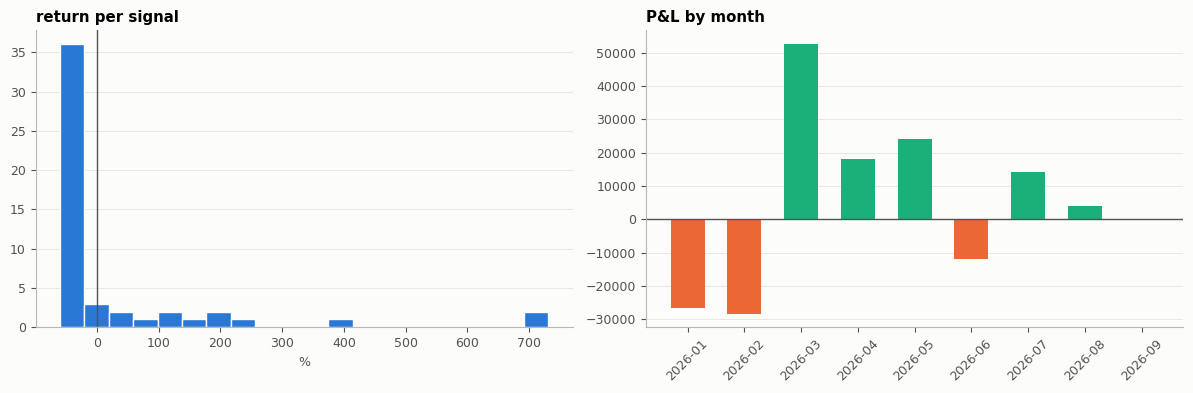

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(res.ret, bins=20, color=CAT[0], edgecolor=SURF)
ax[0].axvline(0, color=INK2, lw=1)
ax[0].set_title('return per signal', loc='left', weight='bold'); ax[0].set_xlabel('%')

res['month'] = res.swept_at.dt.strftime('%Y-%m')
m = res.groupby('month').pnl.sum()
ax[1].bar(m.index, m.values, color=np.where(m.values >= 0, CAT[2], CAT[1]), width=.6)
ax[1].axhline(0, color=INK2, lw=1)
ax[1].set_title('P&L by month', loc='left', weight='bold'); ax[1].tick_params(axis='x', rotation=45)
for a in ax: a.grid(axis='y', color=MUTED, alpha=.35, lw=.6); a.set_axisbelow(True)
plt.tight_layout(); plt.show()

## Does the market backdrop explain the outcomes?

Joins each signal to SPY/QQQ returns and the 10Y proxy change over its holding
window. With ~50 signals these correlations are indicative at best.

In [11]:
ctx = []
for _, r in res.iterrows():
    a = r.swept_at; b = pd.Timestamp(r.our_exp, tz=a.tz) + pd.Timedelta(hours=16)
    w = mkt_h.loc[(mkt_h.index >= a) & (mkt_h.index <= b)]
    if len(w) < 2: ctx.append((np.nan,)*3); continue
    ctx.append(((w.SPY.iloc[-1]/w.SPY.iloc[0]-1)*100,
                (w.QQQ.iloc[-1]/w.QQQ.iloc[0]-1)*100,
                w.y10_proxy.iloc[-1]-w.y10_proxy.iloc[0]))
res[['spy_ret','qqq_ret','d_y10']] = pd.DataFrame(ctx, index=res.index)

from scipy.stats import spearmanr
for c in ['spy_ret','qqq_ret','d_y10']:
    s = res[[c,'ret']].dropna()
    print(f'{c:>8}  IC vs signal return: {spearmanr(s[c], s.ret).correlation:+.3f}   n={len(s)}')

res.groupby(res.right).agg(n=('ret','size'), mean=('ret','mean'),
                           win=('ret', lambda v: 100*(v>0).mean())).round(1)

 spy_ret  IC vs signal return: -0.017   n=51
 qqq_ret  IC vs signal return: +0.085   n=51
   d_y10  IC vs signal return: +0.061   n=51


,n,mean,win
right,,,
C,31,13.1,25.8
P,20,23.9,35.0


## Notes

- `EXPIRY_RULE='match_if_short'` encodes the one conditional result with real
  separation: on sweeps with DTE <= 3 the institution's own expiry returned **+30%**
  while substituting the monthly returned **-45%**. Everything longer favours the monthly.
- The `-60%` stop was the largest single improvement found (-61.8% -> -3.9% at
  $10k/position). It fires on roughly three quarters of positions, so it is the
  dominant exit, not a tail guard.
- Filters that helped all came from reasoning about the instrument — earnings veto,
  degenerate quotes, listing history, split reconciliation. Every statistical search
  over features came back empty.
- The most useful thing you can do to this notebook is give it more rows.